# Opening Diversity vs Specialization

This notebook runs a player-centric experiment for the question:

> Does opening diversity correlate with better results, or do specialists do better?

The workflow is:
1. Build a player-game panel using only pre-game information.
2. Create diversity and specialization features from each player's prior opening history.
3. Run descriptive analysis by diversity and specialization buckets.
4. Train a simple linear baseline (`Ridge`) and a stronger nonlinear sklearn model (`HistGradientBoostingRegressor`).
5. Save metrics, predictions, and plots into the `Player_behaviour` folder.

The target is player-level `expected_score` from the player's perspective:
- `1.0` for a win
- `0.5` for a draw
- `0.0` for a loss


In [1]:
import os
import warnings
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
ROOT = Path('/Users/phamhoanghai/Ureca')
DATA_PATH = ROOT / 'dataset' / 'final_data'
CLUSTER_PATH = ROOT / 'Question_three' / 'output' / 'player_archetypes.csv'
NOTEBOOK_DIR = ROOT / 'Player_behaviour'
OUTPUT_DIR = NOTEBOOK_DIR / 'output'
PLOT_DIR = NOTEBOOK_DIR / 'plots'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MIN_HISTORY_GAMES = 10
USE_EQUAL_ELO_FILTER = False
ELO_TOLERANCE = 25
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
RANDOM_STATE = 42

RAW_COLUMNS = [
    'GameID', 'Event', 'White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric',
    'Opening', 'OpeningFamily', 'Result'
]

print(DATA_PATH)
print(CLUSTER_PATH)
print('Output dir:', OUTPUT_DIR)
print('Plot dir:', PLOT_DIR)


/Users/phamhoanghai/Ureca/dataset/final_data
/Users/phamhoanghai/Ureca/Question_three/output/player_archetypes.csv
Output dir: /Users/phamhoanghai/Ureca/Player_behaviour/output
Plot dir: /Users/phamhoanghai/Ureca/Player_behaviour/plots


In [3]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def standardize_schema(df: pd.DataFrame) -> pd.DataFrame:
    out = df.rename(columns={
        'GameID': 'game_id',
        'Event': 'event',
        'White': 'white_player',
        'Black': 'black_player',
        'WhiteEloNumeric': 'white_elo',
        'BlackEloNumeric': 'black_elo',
        'Opening': 'opening_name',
        'OpeningFamily': 'opening_family',
        'Result': 'result',
    }).copy()

    out['game_id'] = pd.to_numeric(out['game_id'], errors='coerce')
    out['white_elo'] = pd.to_numeric(out['white_elo'], errors='coerce')
    out['black_elo'] = pd.to_numeric(out['black_elo'], errors='coerce')
    out['opening_name'] = out['opening_name'].fillna('Unknown').astype(str)
    out['opening_family'] = out['opening_family'].fillna('Unknown').astype(str)
    out['event'] = out['event'].fillna('Unknown').astype(str)

    out = out.dropna(subset=['game_id', 'white_player', 'black_player', 'white_elo', 'black_elo', 'result'])
    out = out.sort_values(['game_id', 'white_player', 'black_player'], kind='mergesort').reset_index(drop=True)
    out['elo_diff'] = out['white_elo'] - out['black_elo']
    out['abs_elo_diff'] = out['elo_diff'].abs()
    out['avg_elo'] = (out['white_elo'] + out['black_elo']) / 2.0
    return out


def white_score_from_result(result: str) -> float:
    mapping = {
        '1-0': 1.0,
        '0-1': 0.0,
        '1/2-1/2': 0.5,
        '0.5-0.5': 0.5,
        '1': 1.0,
        '0': 0.0,
        '0.5': 0.5,
        'win': 1.0,
        'loss': 0.0,
        'draw': 0.5,
    }
    return mapping.get(str(result).strip(), np.nan)


def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return np.nan
    probs = np.array(list(counter.values()), dtype=float) / total
    return float(-(probs * np.log2(probs)).sum())


def top_share(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return np.nan
    return max(counter.values()) / total


def effective_openings(entropy: float) -> float:
    if pd.isna(entropy):
        return np.nan
    return float(2 ** entropy)


def elo_bucket(avg_elo: float) -> str:
    if avg_elo < 1200:
        return 'under_1200'
    if avg_elo < 1400:
        return '1200_1399'
    if avg_elo < 1600:
        return '1400_1599'
    if avg_elo < 1800:
        return '1600_1799'
    if avg_elo < 2000:
        return '1800_1999'
    if avg_elo < 2200:
        return '2000_2199'
    return 'over_2200'


def build_player_panel(df: pd.DataFrame) -> pd.DataFrame:
    player_stats = defaultdict(lambda: {
        'games': 0,
        'score_sum': 0.0,
        'openings': Counter(),
        'families': Counter(),
    })
    rows = defaultdict(list)

    for row in df.itertuples(index=False):
        white_score = white_score_from_result(row.result)
        if pd.isna(white_score):
            continue
        black_score = 0.5 if white_score == 0.5 else 1.0 - white_score

        perspectives = [
            ('white', row.white_player, row.black_player, row.white_elo, row.black_elo, row.elo_diff, white_score),
            ('black', row.black_player, row.white_player, row.black_elo, row.white_elo, -row.elo_diff, black_score),
        ]

        for color, player, opponent, player_elo, opponent_elo, elo_diff, score in perspectives:
            stats = player_stats[player]
            opening_entropy = shannon_entropy(stats['openings'])
            family_entropy = shannon_entropy(stats['families'])

            rows['game_id'].append(row.game_id)
            rows['player'].append(player)
            rows['opponent'].append(opponent)
            rows['color'].append(color)
            rows['event'].append(row.event)
            rows['opening_name'].append(row.opening_name)
            rows['opening_family'].append(row.opening_family)
            rows['player_elo'].append(player_elo)
            rows['opponent_elo'].append(opponent_elo)
            rows['elo_diff'].append(elo_diff)
            rows['abs_elo_diff'].append(abs(elo_diff))
            rows['avg_elo'].append((player_elo + opponent_elo) / 2.0)
            rows['expected_score'].append(score)
            rows['games_played_before'].append(stats['games'])
            rows['prior_expected_score'].append(stats['score_sum'] / stats['games'] if stats['games'] else np.nan)
            rows['opening_entropy'].append(opening_entropy)
            rows['family_entropy'].append(family_entropy)
            rows['effective_openings'].append(effective_openings(opening_entropy))
            rows['unique_openings'].append(len(stats['openings']))
            rows['unique_families'].append(len(stats['families']))
            rows['top_opening_share'].append(top_share(stats['openings']))
            rows['top_family_share'].append(top_share(stats['families']))

        white_stats = player_stats[row.white_player]
        white_stats['games'] += 1
        white_stats['score_sum'] += white_score
        white_stats['openings'][row.opening_name] += 1
        white_stats['families'][row.opening_family] += 1

        black_stats = player_stats[row.black_player]
        black_stats['games'] += 1
        black_stats['score_sum'] += black_score
        black_stats['openings'][row.opening_name] += 1
        black_stats['families'][row.opening_family] += 1

    panel = pd.DataFrame(rows)
    panel['elo_bracket'] = panel['avg_elo'].map(elo_bucket)
    panel['specialization_score'] = panel['top_opening_share']
    panel['opening_entropy_sq'] = panel['opening_entropy'] ** 2
    panel['specialization_score_sq'] = panel['specialization_score'] ** 2
    return panel


def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0.0, 1.0)
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


In [4]:
raw_df = pd.read_csv(DATA_PATH, usecols=RAW_COLUMNS)
game_df = standardize_schema(raw_df)
panel_df = build_player_panel(game_df)

if CLUSTER_PATH.exists():
    cluster_df = pd.read_csv(CLUSTER_PATH)[['player', 'cluster_id', 'archetype']].copy()
    player_cluster = cluster_df.rename(columns={'player': 'player', 'cluster_id': 'player_cluster_id', 'archetype': 'player_archetype'})
    opponent_cluster = cluster_df.rename(columns={'player': 'opponent', 'cluster_id': 'opponent_cluster_id', 'archetype': 'opponent_archetype'})
    panel_df = panel_df.merge(player_cluster, on='player', how='left').merge(opponent_cluster, on='opponent', how='left')
else:
    panel_df['player_cluster_id'] = np.nan
    panel_df['opponent_cluster_id'] = np.nan
    panel_df['player_archetype'] = 'Unknown'
    panel_df['opponent_archetype'] = 'Unknown'

panel_df['player_archetype'] = panel_df['player_archetype'].fillna('Unknown')
panel_df['opponent_archetype'] = panel_df['opponent_archetype'].fillna('Unknown')

model_df = panel_df[panel_df['games_played_before'] >= MIN_HISTORY_GAMES].copy()
if USE_EQUAL_ELO_FILTER:
    model_df = model_df[model_df['abs_elo_diff'] <= ELO_TOLERANCE].copy()

model_df = model_df.sort_values('game_id').reset_index(drop=True)

print('Raw games:', len(game_df))
print('Player-centric rows:', len(panel_df))
print('Model rows after history filter:', len(model_df))
print(model_df[['expected_score', 'opening_entropy', 'specialization_score']].describe())

model_df.head()


Raw games: 1111082
Player-centric rows: 2222164
Model rows after history filter: 2015958
       expected_score  opening_entropy  specialization_score
count    2.015958e+06     2.015958e+06          2.015958e+06
mean     5.030430e-01     5.070125e+00          1.355423e-01
std      4.906395e-01     1.100075e+00          9.605239e-02
min      0.000000e+00    -0.000000e+00          1.863354e-02
25%      0.000000e+00     4.326337e+00          7.286673e-02
50%      5.000000e-01     5.167552e+00          1.071429e-01
75%      1.000000e+00     5.871941e+00          1.666667e-01
max      1.000000e+00     8.266662e+00          1.000000e+00


,game_id,player,opponent,color,event,opening_name,opening_family,player_elo,opponent_elo,elo_diff,abs_elo_diff,avg_elo,expected_score,games_played_before,prior_expected_score,opening_entropy,family_entropy,effective_openings,unique_openings,unique_families,top_opening_share,top_family_share,elo_bracket,specialization_score,opening_entropy_sq,specialization_score_sq,player_cluster_id,player_archetype,opponent_cluster_id,opponent_archetype
0,450,igo1,pseudoknight,white,Rated Bullet game,Sicilian Defense: Alapin Variation,Semi-Open Defenses,2059.0,1854.0,205.0,205.0,1956.5,1.0,10,0.6,2.370951,1.000000,5.172819,6,2,0.3,0.5,1800_1999,0.3,5.621407,0.09,0.0,Hypermodern Strategists,0.0,Hypermodern Strategists
1,452,Slavik-7,andrewrun,black,Rated Bullet game,Italian Game: Hungarian Defense,Open Games and Semi-Open,2597.0,2237.0,360.0,360.0,2417.0,1.0,10,1.0,2.921928,1.295462,7.578583,8,3,0.2,0.6,over_2200,0.2,8.537664,0.04,0.0,Hypermodern Strategists,2.0,Counterpunching Defenders
2,471,Rahstah,falanx,white,Rated Bullet game,Scandinavian Defense,Semi-Open Defenses,1611.0,1649.0,-38.0,38.0,1630.0,0.0,10,0.3,1.760964,0.970951,3.389245,4,2,0.5,0.6,1600_1799,0.5,3.100994,0.25,1.0,Aggressive Attackers,3.0,Positional Defenders
3,471,falanx,Rahstah,black,Rated Bullet game,Scandinavian Defense,Semi-Open Defenses,1649.0,1611.0,38.0,38.0,1630.0,1.0,10,0.7,1.760964,0.970951,3.389245,4,2,0.5,0.6,1600_1799,0.5,3.100994,0.25,3.0,Positional Defenders,1.0,Aggressive Attackers
4,475,DolfjeWeerwolfje,guantebla,black,Rated Bullet game,Pirc Defense #4,Semi-Open Defenses,1817.0,1755.0,62.0,62.0,1786.0,1.0,10,0.8,2.321928,1.521928,5.000000,6,3,0.4,0.4,1600_1799,0.4,5.391350,0.16,2.0,Counterpunching Defenders,2.0,Counterpunching Defenders


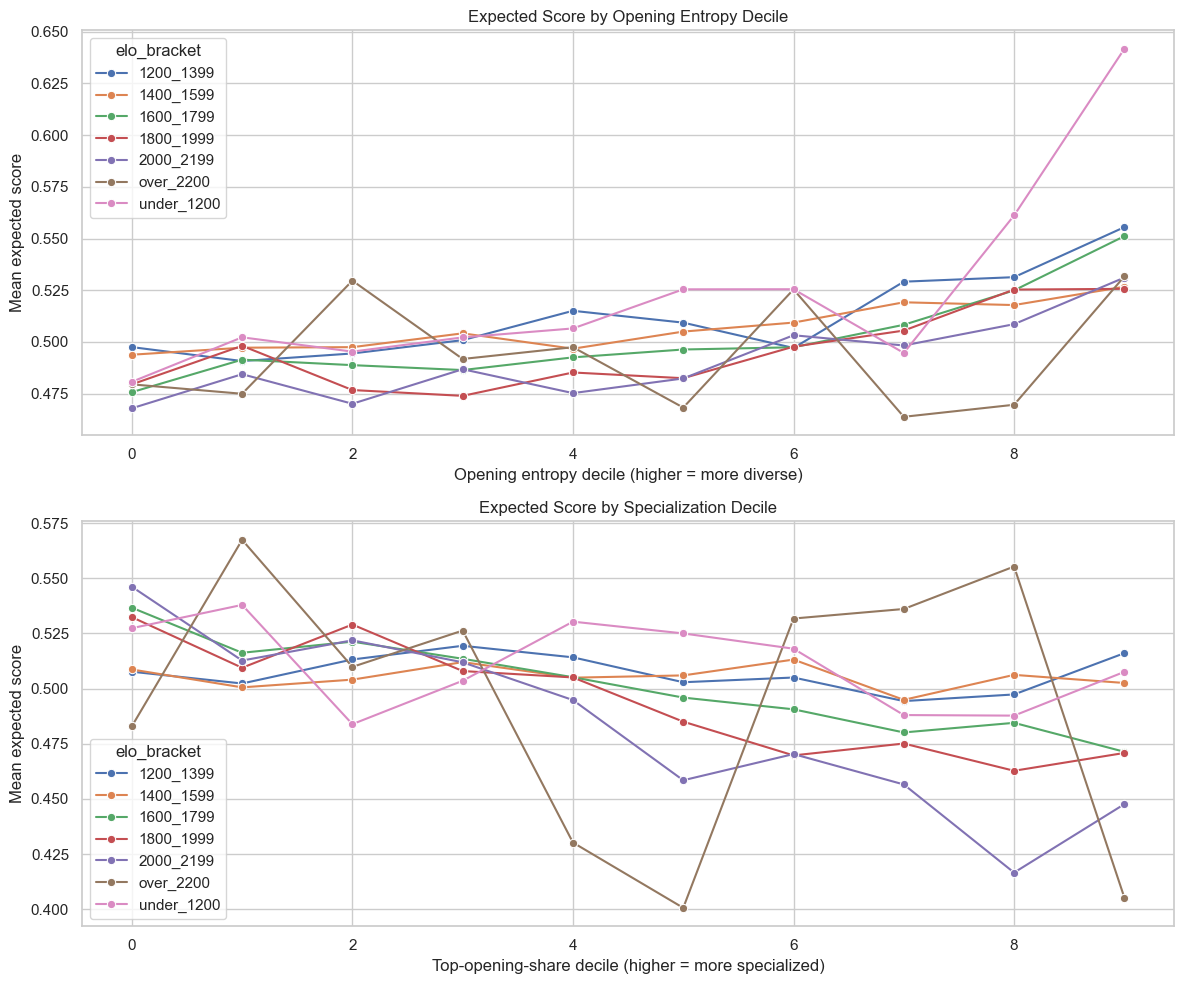

,elo_bracket,diversity_decile,mean_expected_score,rows
0,1200_1399,0,0.497495,34127
1,1200_1399,1,0.490747,31287
2,1200_1399,2,0.494415,27305
3,1200_1399,3,0.500860,27335
4,1200_1399,4,0.515056,26733
5,1200_1399,5,0.509327,23963
6,1200_1399,6,0.497079,24304
7,1200_1399,7,0.529135,19993
8,1200_1399,8,0.531316,15567
9,1200_1399,9,0.555506,9999


,elo_bracket,specialist_decile,mean_expected_score,rows
0,1200_1399,0,0.507627,13177
1,1200_1399,1,0.502285,21008
2,1200_1399,2,0.513165,21306
3,1200_1399,3,0.519374,22221
4,1200_1399,4,0.514141,24044
5,1200_1399,5,0.502854,25931
6,1200_1399,6,0.504991,22840
7,1200_1399,7,0.494311,27510
8,1200_1399,8,0.497318,29834
9,1200_1399,9,0.516034,32742


In [5]:
plot_df = model_df.dropna(subset=['opening_entropy', 'specialization_score']).copy()
plot_df['diversity_decile'] = pd.qcut(plot_df['opening_entropy'], 10, labels=False, duplicates='drop')
plot_df['specialist_decile'] = pd.qcut(plot_df['specialization_score'], 10, labels=False, duplicates='drop')

diversity_summary = (
    plot_df.groupby(['elo_bracket', 'diversity_decile'], observed=True)
    .agg(mean_expected_score=('expected_score', 'mean'), rows=('expected_score', 'size'))
    .reset_index()
)
specialist_summary = (
    plot_df.groupby(['elo_bracket', 'specialist_decile'], observed=True)
    .agg(mean_expected_score=('expected_score', 'mean'), rows=('expected_score', 'size'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
sns.lineplot(data=diversity_summary, x='diversity_decile', y='mean_expected_score', hue='elo_bracket', marker='o', ax=axes[0])
axes[0].set_title('Expected Score by Opening Entropy Decile')
axes[0].set_xlabel('Opening entropy decile (higher = more diverse)')
axes[0].set_ylabel('Mean expected score')

sns.lineplot(data=specialist_summary, x='specialist_decile', y='mean_expected_score', hue='elo_bracket', marker='o', ax=axes[1])
axes[1].set_title('Expected Score by Specialization Decile')
axes[1].set_xlabel('Top-opening-share decile (higher = more specialized)')
axes[1].set_ylabel('Mean expected score')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'diversity_and_specialization_deciles.png', dpi=200)
plt.show()

diversity_summary.to_csv(OUTPUT_DIR / 'diversity_decile_summary.csv', index=False)
specialist_summary.to_csv(OUTPUT_DIR / 'specialization_decile_summary.csv', index=False)

display(diversity_summary.head(15))
display(specialist_summary.head(15))


In [6]:
split_1 = int(len(model_df) * TRAIN_FRAC)
split_2 = int(len(model_df) * (TRAIN_FRAC + VAL_FRAC))

train_df = model_df.iloc[:split_1].copy()
val_df = model_df.iloc[split_1:split_2].copy()
test_df = model_df.iloc[split_2:].copy()

NUM_FEATURES = [
    'player_elo', 'opponent_elo', 'elo_diff', 'abs_elo_diff', 'avg_elo',
    'games_played_before', 'prior_expected_score',
    'opening_entropy', 'opening_entropy_sq', 'family_entropy',
    'effective_openings', 'unique_openings', 'unique_families',
    'top_opening_share', 'top_family_share',
    'specialization_score', 'specialization_score_sq',
    'player_cluster_id', 'opponent_cluster_id',
]
CAT_FEATURES = ['color', 'event', 'opening_family', 'elo_bracket', 'player_archetype', 'opponent_archetype']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), NUM_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_one_hot_encoder()),
        ]), CAT_FEATURES),
    ],
    sparse_threshold=0,
)

X_train = preprocessor.fit_transform(train_df)
X_val = preprocessor.transform(val_df)
X_test = preprocessor.transform(test_df)

y_train = train_df['expected_score'].to_numpy()
y_val = val_df['expected_score'].to_numpy()
y_test = test_df['expected_score'].to_numpy()

print('Train rows:', len(train_df))
print('Validation rows:', len(val_df))
print('Test rows:', len(test_df))
print('Train matrix shape:', X_train.shape)
print('Validation matrix shape:', X_val.shape)
print('Test matrix shape:', X_test.shape)


Train rows: 1411170
Validation rows: 302394
Test rows: 302394
Train matrix shape: (1411170, 1333)
Validation matrix shape: (302394, 1333)
Test matrix shape: (302394, 1333)


In [7]:
baseline_pred = np.full(len(y_test), y_train.mean())

ridge = Ridge(alpha=2.0)
ridge.fit(X_train, y_train)
ridge_val_pred = np.clip(ridge.predict(X_val), 0.0, 1.0)
ridge_test_pred = np.clip(ridge.predict(X_test), 0.0, 1.0)

hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_leaf_nodes=31,
    min_samples_leaf=40,
    l2_regularization=0.1,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)
hgbr.fit(X_train, y_train)
hgbr_val_pred = np.clip(hgbr.predict(X_val), 0.0, 1.0)
hgbr_test_pred = np.clip(hgbr.predict(X_test), 0.0, 1.0)

metrics_df = pd.DataFrame([
    {'model': 'baseline_mean', **regression_metrics(y_test, baseline_pred)},
    {'model': 'ridge', **regression_metrics(y_test, ridge_test_pred)},
    {'model': 'hist_gradient_boosting', **regression_metrics(y_test, hgbr_test_pred)},
]).sort_values('rmse').reset_index(drop=True)

val_metrics_df = pd.DataFrame([
    {'model': 'ridge', **regression_metrics(y_val, ridge_val_pred)},
    {'model': 'hist_gradient_boosting', **regression_metrics(y_val, hgbr_val_pred)},
]).sort_values('rmse').reset_index(drop=True)

display(val_metrics_df)
display(metrics_df)

test_predictions = test_df[[
    'game_id', 'player', 'opponent', 'color', 'event', 'opening_family', 'elo_bracket',
    'expected_score', 'opening_entropy', 'specialization_score', 'prior_expected_score'
]].copy()
test_predictions['baseline_pred'] = baseline_pred
test_predictions['ridge_pred'] = ridge_test_pred
test_predictions['hgbr_pred'] = hgbr_test_pred

metrics_df.to_csv(OUTPUT_DIR / 'model_metrics.csv', index=False)
val_metrics_df.to_csv(OUTPUT_DIR / 'validation_metrics.csv', index=False)
test_predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

test_predictions.head()


,model,rmse,mae,r2
0,hist_gradient_boosting,0.452193,0.413682,0.150817
1,ridge,0.453129,0.418235,0.147299


,model,rmse,mae,r2
0,hist_gradient_boosting,0.451544,0.412475,0.153602
1,ridge,0.452522,0.417084,0.149930
2,baseline_mean,0.490811,0.481904,-0.000006


,game_id,player,opponent,color,event,opening_family,elo_bracket,expected_score,opening_entropy,specialization_score,prior_expected_score,baseline_pred,ridge_pred,hgbr_pred
1713564,952354,mabinogi,StojanovicSrbija,black,Rated Classical game,Closed and Semi-Closed,1800_1999,0.0,5.222548,0.103896,0.532468,0.50333,0.343395,0.304931
1713565,952355,jmac26,andjev,white,Rated Blitz game,Semi-Open Defenses,1800_1999,1.0,6.026752,0.072368,0.450658,0.50333,0.502869,0.507463
1713566,952355,andjev,jmac26,black,Rated Blitz game,Semi-Open Defenses,1800_1999,0.0,6.937182,0.078621,0.506897,0.50333,0.484442,0.500412
1713567,952356,milindsg,aslk,white,Rated Blitz game,Semi-Open Defenses,1400_1599,1.0,5.903149,0.110526,0.434211,0.50333,0.676924,0.725350
1713568,952356,aslk,milindsg,black,Rated Blitz game,Semi-Open Defenses,1400_1599,0.0,5.404677,0.085526,0.381579,0.50333,0.310728,0.273588


In [8]:
feature_names = preprocessor.get_feature_names_out()
ridge_coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': ridge.coef_})
    .assign(abs_coefficient=lambda d: d['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .reset_index(drop=True)
)

perm_rows = min(len(y_val), 50000)
perm = permutation_importance(
    hgbr,
    X_val[:perm_rows],
    y_val[:perm_rows],
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
)

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': perm.importances_mean})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

ridge_coef_df.to_csv(OUTPUT_DIR / 'ridge_coefficients.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'hgbr_permutation_importance.csv', index=False)
model_df.head(200000).to_csv(OUTPUT_DIR / 'player_panel_sample.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=ridge_coef_df.head(15),
    x='coefficient',
    y='feature',
    color='#ad7c59',
    ax=axes[0],
)
axes[0].set_title('Top Ridge Coefficients')
axes[0].set_xlabel('Coefficient')
axes[0].set_ylabel('Feature')

sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature',
    color='#2f6c8f',
    ax=axes[1],
)
axes[1].set_title('Top HGBR Permutation Importances')
axes[1].set_xlabel('Validation importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_interpretation.png', dpi=200)
plt.show()

display(ridge_coef_df.head(15))
display(importance_df.head(15))


KeyboardInterrupt: 

## Optional Deep-Learning Extension

This environment does not currently have `torch` installed, so the notebook keeps the runnable experiment fully sklearn-based.

If you want to extend this later in PyTorch, the next step would be a tabular MLP with:
- numeric inputs: diversity, specialization, Elo, experience, and prior score features
- categorical embeddings: `event`, `opening_family`, `elo_bracket`, `player_archetype`, `opponent_archetype`
- output: a single regression value clipped to `[0, 1]` for expected score
- loss: `MSELoss`

That would make a good advanced comparison model after the linear and histogram-gradient-boosting baselines above.
